<a href="https://colab.research.google.com/github/Andreina-A/Data620/blob/main/FinalProjectData620.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Andreina Arias
<br>Data 620
<br>Final Project

**Fake Review Detection Using Text Analysis**

Online product reviews strongly influence consumer purchasing decisions. Many customers rely on reviews to evaluate product quality, reliability, and overall satisfactio before makine perchases. Unfortunately, there is a growning concern of fake or deceptive reviews which are misleading and can distort consumer perceptions and reduce trust in review systems.
<br>This project aims to develop a model that can distinguish between genuine and fake products reviews using text analysis techniques. By applying natural language processing (NLP) methods and classification algorithms, the project will investigate whether textual patterns can identify deceptive reviews.
The motivation behind this analysis is to explore how NLP and machine learning can be used to improve trust in online platforms by identifying patterns associated with fake contents. To evaluate performance, I used metrics like accuracy, precision, recall, and F1-score

<br>Main question to answer: Can text features be used to reliably distinguish fakes views from genuine reviews? My hypothesize is that fake reviews will patterns that are easy to detect, such as overly positive or exaggerated language, lack of specific details, or repetitive phrases, which can allow machine learning models to classify fake reviews with reasonable accuracy.

<br> This project will use the Deceptive Opinion Spam Corpus dataset from kaggle. The dataset is licensed under the CC BY-NC-SA 4.0. (https://creativecommons.org/licenses/by-nc-sa/4.0/). The dataset contains hotel reviews labeled as either Truthful or Deceptive, this will be my target label, it also contains review text which will serve as the primary feature for analysis. The dataset is made up of 1600 observations and 5 variables.
Variables:
<br>•Deceptive
<br>•Hotel
<br>•Polarity
<br>•Source
<br>•Text

**Loading Data** <br>Loaded data directly from Kaggle using the kagglehub package. After loading the data I otained the structure and verified its columns and dimensions.

In [4]:
#Libraries and NLP Libraries
import pandas as pd
import numpy as np
import string
import re
import kagglehub
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

#Loading data instructions from kaggle (https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas)
#Obtained path to dataset in kaggle for download
path = kagglehub.dataset_download("rtatman/deceptive-opinion-spam-corpus")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'deceptive-opinion-spam-corpus' dataset.
Path to dataset files: /kaggle/input/deceptive-opinion-spam-corpus


In [5]:
# The path variable from the previous cell contains the directory where the dataset was downloaded.
path_to_downloaded_dataset = "/kaggle/input/deceptive-opinion-spam-corpus"
print(f"Contents of the dataset directory '{path_to_downloaded_dataset}':")
for item in os.listdir(path_to_downloaded_dataset):
    print(f"- {item}")

file_name = "deceptive-opinion.csv" #file name in kaggle

# The function handles finding the file within the downloaded dataset's directory.
print(f"Attempting to load file: {file_name} from dataset handle")

# Load the latest version using dataset_load
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "rtatman/deceptive-opinion-spam-corpus",
  file_name,
)

print("First 5 records:", df.head())

Contents of the dataset directory '/kaggle/input/deceptive-opinion-spam-corpus':
- .nfs0000000049eb88a30000000f
- deceptive-opinion.csv
Attempting to load file: deceptive-opinion.csv from dataset handle
Using Colab cache for faster access to the 'deceptive-opinion-spam-corpus' dataset.
First 5 records:   deceptive   hotel  polarity       source  \
0  truthful  conrad  positive  TripAdvisor   
1  truthful   hyatt  positive  TripAdvisor   
2  truthful   hyatt  positive  TripAdvisor   
3  truthful    omni  positive  TripAdvisor   
4  truthful   hyatt  positive  TripAdvisor   

                                                text  
0  We stayed for a one night getaway with family ...  
1  Triple A rate with upgrade to view room was le...  
2  This comes a little late as I'm finally catchi...  
3  The Omni Chicago really delivers on all fronts...  
4  I asked for a high floor away from the elevato...  


In [8]:
df.shape

(1600, 5)

In [10]:
print("Columns:",df.columns)

Columns: Index(['deceptive', 'hotel', 'polarity', 'source', 'text'], dtype='object')


**Data Cleaning/Preprocessing**
<br> For data cleaning I converted all text to lowercase, removed punctuation, removed numbers, and removed extra whitespace.

In [11]:
#Tidy data for analysis
#function to clean text review
def clean_text(text):
    text=re.sub(r'\d+','',text) #removed digits
    text = text.translate(str.maketrans('', '', string.punctuation))#removed punctuation
    text = text.lower() #converted all text to lowercase
    text=text.strip() #removed leading and trailing spaces
    return text

In [12]:
#cleaned the function
df['clean_text']=df['text'].apply(clean_text)

#converted deceptive column in numeric
df['deceptive']=df['deceptive'].map({
    'truthful':0,
    'deceptive':1
})

#obtained features and target
X=df['clean_text']
y=df['deceptive']

**Exploratory Data Analysis**
<br> A new feature called review_legnth was created by calculating the number of characters in each cleaned review. The avaergae review lengt for truthful and deceptive reviews was visualized using a bar graph. This analysis suggested that there may be noticebale difference between fake and genuine reviews in terms of writing style and review legnth, supporting the idea that textual patterns can help classify decptive content.

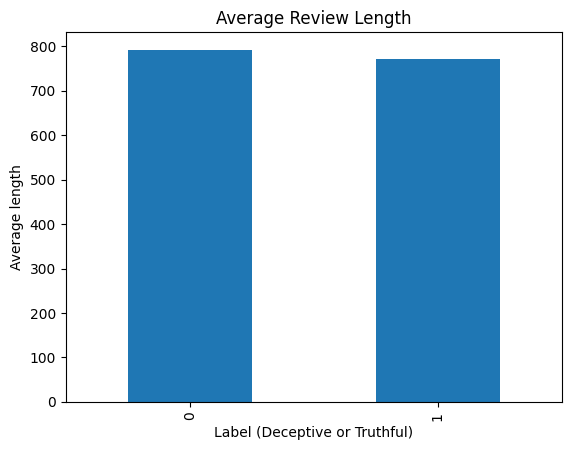

In [13]:
#exploratory data analysis visual
df['review_length']=df['clean_text'].apply(len)
df.groupby('deceptive')['review_length'].mean().plot(kind="bar")

plt.title("Average Review Length")
plt.xlabel("Label (Deceptive or Truthful)")
plt.ylabel("Average length")
plt.show()

**Feature extraction**<br> Machine learning algorithms require numercial input, therefore the text reviews was converted into numerical features using Term Frequency-Inverse Document Frequency (TF-IDF) Vectorization. TF-IDF measure how important a word is within a document relative to the entire dataset. The vetorizer removed common English stop words and limited the vocabulary to the top 5,000 features.

In [16]:
#TF-ID Vectorization
vectorizer=TfidfVectorizer(stop_words='english', max_features=5000)
X_vectorized=vectorizer.fit_transform(X)

The dataset was divided into 80% training and 20% testing.

In [17]:
#test/train data split
X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=42)

**Machine Learning Models**
<br> The three classfication models used were Logistic Regression, Naive Bayes, and Support Vector Machine (SVM).

Logistic regression was trained on the TF-IDF features and used to predict whether the reviews were deceptive or truthful

In [18]:
#Logistic regression model
lr_model=LogisticRegression()
lr_model.fit(X_train, y_train)
lr_predictions=lr_model.predict(X_test)

print("Logistic Regression Results")
print(classification_report(y_test, lr_predictions))
print("Accuracy:", accuracy_score(y_test, lr_predictions))


Logistic Regression Results
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       168
           1       0.87      0.89      0.88       152

    accuracy                           0.89       320
   macro avg       0.89      0.89      0.89       320
weighted avg       0.89      0.89      0.89       320

Accuracy: 0.8875


A multinomial Naive bayes classifier was test because it is commonly used for text classficiation.

In [19]:
#Naive Bayes Model
nb_model=MultinomialNB()
nb_model.fit(X_train, y_train)
nb_predictions=nb_model.predict(X_test)

print("Naive Bayes Results")
print("Accuracy:", accuracy_score(y_test, nb_predictions))

print(classification_report(y_test, nb_predictions))

Naive Bayes Results
Accuracy: 0.875
              precision    recall  f1-score   support

           0       0.93      0.83      0.87       168
           1       0.83      0.93      0.88       152

    accuracy                           0.88       320
   macro avg       0.88      0.88      0.87       320
weighted avg       0.88      0.88      0.87       320



A linear SVM classifier was implemented. This model can be highly effective because it performs well in high dimensional feature spaces such as TF-IDF.

In [20]:
#Support vector machine
svm_model=LinearSVC()
svm_model.fit(X_train, y_train)
svm_predictions=svm_model.predict(X_test)

print("Support Vector Machine Results")
print("Accuracy:", accuracy_score(y_test, svm_predictions))
print(classification_report(y_test, svm_predictions))

Support Vector Machine Results
Accuracy: 0.8875
              precision    recall  f1-score   support

           0       0.90      0.89      0.89       168
           1       0.88      0.89      0.88       152

    accuracy                           0.89       320
   macro avg       0.89      0.89      0.89       320
weighted avg       0.89      0.89      0.89       320



In [21]:
#confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, lr_predictions))

Confusion Matrix:
[[148  20]
 [ 16 136]]


**Model Evaluation**
<br>Compare accuracy, precision, recall, and F1-score.

In [22]:
#comparsion table
comparison_table = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'Support Vector Machine'],
    'Accuracy': [accuracy_score(y_test, lr_predictions), accuracy_score(y_test, nb_predictions), accuracy_score(y_test, svm_predictions)],
    'Precision': [precision_score(y_test, lr_predictions), precision_score(y_test, nb_predictions), precision_score(y_test, svm_predictions)],
    'Recall': [recall_score(y_test, lr_predictions), recall_score(y_test, nb_predictions), recall_score(y_test, svm_predictions)],
    'F1-Score': [f1_score(y_test, lr_predictions), f1_score(y_test, nb_predictions), f1_score(y_test, svm_predictions)]
})

print(comparison_table.round(2))

                    Model  Accuracy  Precision  Recall  F1-Score
0     Logistic Regression      0.89       0.87    0.89      0.88
1             Naive Bayes      0.88       0.83    0.93      0.88
2  Support Vector Machine      0.89       0.88    0.89      0.88


The coefficients from the logistic regression model was analyzed to better understand the word influence predictions. This analysis helped patterns commonly associated with fake reviews, including exaggerated language and repetitive descriptive terms.

In [23]:
#Most important words
feature_names = vectorizer.get_feature_names_out()
coefs = lr_model.coef_[0]

top_positive=np.argsort(coefs)[-10:]
top_negative=np.argsort(coefs)[:10]

print("\nWords associated with fake reviews:")
for i in top_positive:
    print(feature_names[i])
print("\nWords associated with genuine reviews:")
for i in top_negative:
    print(feature_names[i])


Words associated with fake reviews:
finally
vacation
luxurious
husband
food
experience
staying
luxury
hotel
chicago

Words associated with genuine reviews:
location
floor
small
great
rate
th
michigan
breakfast
helpful
large


**Conclusion**
<br> This project demonstrated that machine learning and natural language processing techniques can successfully identify deceptive online reviews using text patterns. The results support the oringial hypothesis that fake reviews contain easy to identify characteristics such as exaggerated wording, lack of detail, and repetitive language. By transforming review text into numerical features using TF-IDF and applying classfication algorithms, the models were able to distinguish between deceptive and truthful reviews with strong perfomance.
<br> Among the three models, SVM and Logistic regression produced the best overall results. showign that supervised machine mthods are effective for text classification problems. This projected highlighted the importance of NLP techniques in improving trust and transparency in online review systemss. Detecting fake reviews can help consumers make more informed purchases they are would be confident to buy and support the integrity of the online platform.